# 11 - Depth vs Breadth on MNIST

**Section:** FNNs | **Prereqs:** `FNNs/BinaryMNIST.ipynb` | **Next:** `FNNs/MNISToptimizers.ipynb`

The `ANNs/DepthVsBreadth.ipynb` experiment redone on real data: 3 depths
(1/2/3 hidden layers) x 5 widths (50 to 250 units) = 15 models, scored on both
train and test accuracy.

**Why both curves.** On Iris only training accuracy was plotted, which cannot
distinguish 'learned the pattern' from 'memorised the data'. Here the two panels
diverge, and the gap between them *is* overfitting.

**What to expect:** width helps up to a point then flattens; the third hidden
layer buys little at this learning rate and epoch budget. Bigger is not better -
it is just slower, and it overfits sooner.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST

In [2]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:10<00:00, 906kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.36MB/s]


In [ ]:
# The sweep grid: 50-250 units in steps of 50, crossed with 1-3 hidden layers.
nodeNum = np.arange(50,251, 50, dtype=int)
Layers = [1,2,3]

In [ ]:
nodeNum

array([ 50, 100, 150, 200, 250])

In [ ]:
# Flatten both splits to 784-vectors. Labels go to the GPU; the images follow
# inside the training loop.
label = data.targets.to('cuda')
data = data.data.view(-1,784).float()

test_label = test_data.targets.to('cuda')
test_data = test_data.data.view(-1,784).float()

In [ ]:
# Standard loaders: shuffled mini-batches for training, one big batch for test.
train_data = TensorDataset(data,label)
test_data = TensorDataset(test_data,test_label)

bs = 32
data_loader = DataLoader(train_data, batch_size=bs, drop_last=True, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [ ]:
# A model whose depth and width are constructor arguments.
# nn.ModuleList holds a variable number of layers and - unlike a plain Python
# list - registers them, so model.parameters() sees them and the optimizer
# trains them. Layers stored in a bare list are invisible and silently frozen.
class model(nn.Module):
  def __init__(self, numNodes, numLayers):
    super().__init__()

    self.input_layer = nn.Linear(784,  numNodes)

    self.nodeList = nn.ModuleList([nn.Linear(numNodes,numNodes) for _ in range(numLayers)])

    self.output_layer = nn.Linear(numNodes,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    for layer in self.nodeList:
      x = F.relu(layer(x))

    return self.output_layer(x)

In [ ]:
# The training function, parameterised by (numNodes, numLayers) so the sweep
# below is a nested loop. 50 epochs each - shorter than the single-model runs,
# because 15 models have to be trained.
def train_model(numNodes, numLayers):

  classifier = model(numNodes, numLayers).to('cuda')

  epochs = 50
  lr = 0.0001

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      x = x.to('cuda') # Move data to GPU
      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Epoch {i} Layer {numLayers}, Nodes {numNodes}: Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      X = X.to('cuda') # Move test data to GPU
      Preds = torch.argmax(classifier(X), dim = 1)
      test_acc.append( 100 * torch.mean( (Preds == Y).float()).cpu() )


  print()
  return losses, train_acc, test_acc

In [ ]:
# The sweep. Results are stored as object arrays because each cell holds a full
# per-epoch accuracy list rather than a single number.
x, y = len(Layers), len(nodeNum)

train_acc = np.zeros((x, y),dtype=object)
test_acc = np.zeros((x, y),dtype=object)
losses = np.zeros((x, y),dtype=object)

for i in range(x):
    for j in range(y):
        loss, train, test = train_model(nodeNum[j], Layers[i])
        train_acc[i][j] = train
        test_acc[i][j] = test
        losses[i][j] = loss

Epoch 0 Layer 1, Nodes 50: Loss = 0.6638063192367554
Epoch 10 Layer 1, Nodes 50: Loss = 0.04025399312376976
Epoch 20 Layer 1, Nodes 50: Loss = 0.0115886852145195
Epoch 30 Layer 1, Nodes 50: Loss = 0.0063447849825024605
Epoch 40 Layer 1, Nodes 50: Loss = 0.005939855240285397
Epoch 49 Layer 1, Nodes 50: Loss = 0.004723535384982824

Epoch 0 Layer 1, Nodes 100: Loss = 0.5697194337844849
Epoch 10 Layer 1, Nodes 100: Loss = 0.01871548965573311
Epoch 20 Layer 1, Nodes 100: Loss = 0.007884659804403782
Epoch 30 Layer 1, Nodes 100: Loss = 0.006167973857372999
Epoch 40 Layer 1, Nodes 100: Loss = 0.005252982955425978
Epoch 49 Layer 1, Nodes 100: Loss = 0.006086520850658417

Epoch 0 Layer 1, Nodes 150: Loss = 0.46708711981773376
Epoch 10 Layer 1, Nodes 150: Loss = 0.01732560619711876
Epoch 20 Layer 1, Nodes 150: Loss = 0.007905961945652962
Epoch 30 Layer 1, Nodes 150: Loss = 0.00842876173555851
Epoch 40 Layer 1, Nodes 150: Loss = 0.005062143784016371
Epoch 49 Layer 1, Nodes 150: Loss = 0.0054758000

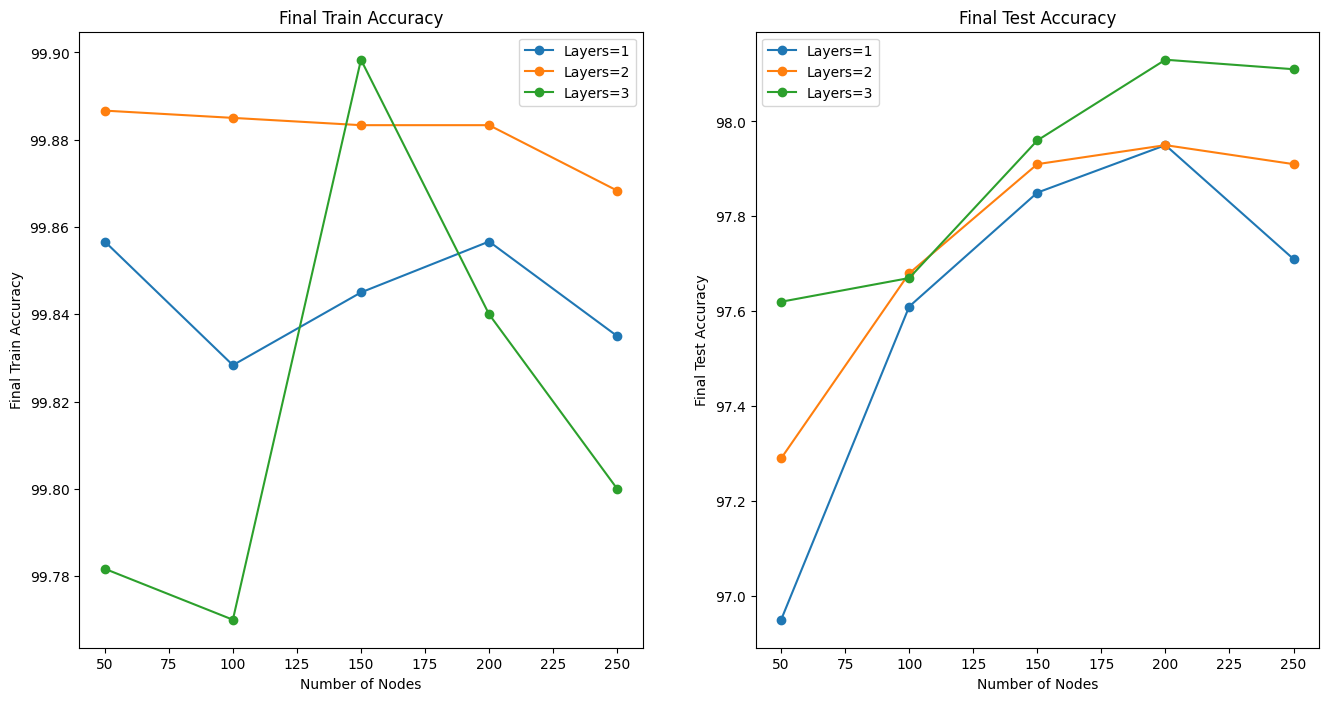

In [ ]:
# Final train accuracy (left) vs final test accuracy (right).
# Read them together: a line that keeps climbing on the left while flat on the
# right is capacity spent on memorising. The best architecture is the smallest
# one whose TEST curve has already plateaued.
fig , ax = plt.subplots(1,2, figsize=(16,8))

for i in range(len(Layers)):
    final_acc = [train_acc[i][j][-1] for j in range(len(nodeNum))]
    ax[0].plot(nodeNum, final_acc, "o-", label=f"Layers={Layers[i]}")

ax[0].set_title("Final Train Accuracy")
ax[0].set_xlabel("Number of Nodes")
ax[0].set_ylabel("Final Train Accuracy")
ax[0].legend()


for i in range(len(Layers)):
    final_acc = [test_acc[i][j][-1] for j in range(len(nodeNum))]
    ax[1].plot(nodeNum, final_acc, "o-", label=f"Layers={Layers[i]}")

ax[1].set_title("Final Test Accuracy")
ax[1].set_xlabel("Number of Nodes")
ax[1].set_ylabel("Final Test Accuracy")
ax[1].legend();